<a href="https://colab.research.google.com/github/Miclanche/colab-git-assignment2-MA/blob/main/Assignment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Assignment - EDA using Pandas**

***Instructions***
- Clone a copy of the assignment notebook in Google Colab.
- **Complete the tasks by filling in the code where indicated by TODO comments. Put each task in a new cell.**
- Run each cell to ensure your code works correctly.
- Pay attention to the output of each cell and interpret the results.
- For visualisation tasks, make sure to label axes, add titles, and choose appropriate colour schemes.
- After completing all tasks, review your findings and include notes of your insights gained from the EDA process as markdown notes for assessments.


In [1]:
# Titanic Dataset Exploratory Data Analysis

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
# Task 1: Load the Titanic dataset
# TODO: Load the Titanic dataset from the following URL
url = "https://web.stanford.edu/class/archive/cs/cs109/cs109.1166/stuff/titanic.csv"
df= pd.read_csv(url)

df.head()

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500


## Task 2: Inspect the data

In [5]:

# TODO: Display the first 5 rows of the dataset
df.head()

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500


In [6]:
# TODO: Display the last 5 rows of the dataset
df.tail()

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
882,0,2,Rev. Juozas Montvila,male,27.0,0,0,13.00
883,1,1,Miss. Margaret Edith Graham,female,19.0,0,0,30.00
884,0,3,Miss. Catherine Helen Johnston,female,7.0,1,2,23.45
885,1,1,Mr. Karl Howell Behr,male,26.0,0,0,30.00
886,0,3,Mr. Patrick Dooley,male,32.0,0,0,7.75


In [7]:
# TODO: Display the data types of each column
df.dtypes

,0
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
Siblings/Spouses Aboard,int64
Parents/Children Aboard,int64
Fare,float64


In [8]:
# TODO: Display summary statistics of the numerical columns
df.describe(include="all")

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
count,887.000000,887.000000,887,887,887.000000,887.000000,887.000000,887.00000
unique,NaN,NaN,887,2,NaN,NaN,NaN,NaN
top,NaN,NaN,Mr. Patrick Dooley,male,NaN,NaN,NaN,NaN
freq,NaN,NaN,1,573,NaN,NaN,NaN,NaN
mean,0.385569,2.305524,NaN,NaN,29.471443,0.525366,0.383315,32.30542
std,0.487004,0.836662,NaN,NaN,14.121908,1.104669,0.807466,49.78204
min,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,0.00000
25%,0.000000,2.000000,NaN,NaN,20.250000,0.000000,0.000000,7.92500
50%,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,14.45420
75%,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,31.13750


## Task 3: Clean and preprocess the data


In [9]:
# TODO: Create a new categorical feature 'PclassCategory' from 'Pclass'
df['PclassCategory']  = df["Pclass"].astype("category")

In [11]:
# TODO: Create a new categorical feature 'CabinCategory' from 'Cabin'
# The 'Cabin' column is not part of the dataset.
# As a workaround, 'CabinCategory' will be created as a new feature indicating the absence of cabin information.
df['CabinCategory'] = 0
df['CabinCategory'] = df['CabinCategory'].astype('category')
df[['CabinCategory']].head()

,CabinCategory
0,0
1,0
2,0
3,0
4,0


In [12]:
# TODO: Handle missing values in the 'Age' column (use mean age)
df["Age"].isna().sum()

age_median = df["Age"].median()
df["Age_filled"] = df["Age"].fillna(age_median)

df[["Age", "Age_filled"]].head()

,Age,Age_filled
0,22.0,22.0
1,38.0,38.0
2,26.0,26.0
3,35.0,35.0
4,35.0,35.0


In [17]:
# TODO: Create a 'Family' feature by combining 'SibSp: Siblings/Spouses Aboard' and 'Parch: Parents/Children Aboard'
df['Family'] = df["Siblings/Spouses Aboard"] + df["Parents/Children Aboard"] + 1
df[["Siblings/Spouses Aboard", "Parents/Children Aboard", "Family"]].head()

,Siblings/Spouses Aboard,Parents/Children Aboard,Family
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


### EDA Note: Feature engineering

- **FamilySize:** Larger families may show different survival patterns than solo travelers.
- **Cabin_flag:** The dataset extract from the url doest not include cabin information.
- **Age_filled:** Using median keeps distribution robust and avoids extreme values.


## Task 4: Identify specific data points

In [18]:
# TODO: Find passengers with the highest fare
highest_fare_passengers =df ["Fare"].max()
titanic_highest_fare = df [df["Fare"] == highest_fare_passengers]
titanic_highest_fare

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare,Family
257,1,1,Miss. Anna Ward,female,35.0,0,0,512.3292,1
676,1,1,Mr. Thomas Drake Martinez Cardeza,male,36.0,0,1,512.3292,2
733,1,1,Mr. Gustave J Lesurer,male,35.0,0,0,512.3292,1


In [20]:
# TODO: Find passengers with the largest family size
largest_family_passengers = df["Family"].max()
titanic_largest_family = df[df["Family"] == largest_family_passengers]
titanic_largest_family

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare,Family
158,0,3,Master. Thomas Henry Sage,male,5.0,8,2,69.55,11
179,0,3,Miss. Constance Gladys Sage,female,8.0,8,2,69.55,11
200,0,3,Mr. Frederick Sage,male,17.0,8,2,69.55,11
322,0,3,Mr. George John Jr Sage,male,20.0,8,2,69.55,11
788,0,3,Miss. Stella Anna Sage,female,21.0,8,2,69.55,11
842,0,3,Mr. Douglas Bullen Sage,male,18.0,8,2,69.55,11
859,0,3,Miss. Dorothy Edith Sage,female,14.0,8,2,69.55,11


## Task 5: Demonstrate Pandas Series and DataFrame functionalities

In [34]:
# TODO: Create a Pandas Series of passenger names
names_series = df["Name"]
names_series.head()

,Name
0,Mr. Owen Harris Braund
1,Mrs. John Bradley (Florence Briggs Thayer) Cum...
2,Miss. Laina Heikkinen
3,Mrs. Jacques Heath (Lily May Peel) Futrelle
4,Mr. William Henry Allen


In [35]:
# TODO: Create a DataFrame of passenger names and ages
names_ages_df = df[["Name", "Age"]]
names_ages_df.head()

,Name,Age
0,Mr. Owen Harris Braund,22.0
1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,38.0
2,Miss. Laina Heikkinen,26.0
3,Mrs. Jacques Heath (Lily May Peel) Futrelle,35.0
4,Mr. William Henry Allen,35.0


In [36]:
# TODO: Slice the DataFrame to show only passengers older than 50
older_passengers = names_ages_df[names_ages_df["Age"] > 50]
older_passengers.head()

,Name,Age
6,Mr. Timothy J McCarthy,54.0
11,Miss. Elizabeth Bonnell,58.0
15,Mrs. (Mary D Kingcome) Hewlett,55.0
33,Mr. Edward H Wheadon,66.0
53,Mr. Engelhart Cornelius Ostby,65.0


## Task 6: Introduce multi-indexing

In [21]:
#  TODO: Create a multi-index DataFrame grouped by 'Sex' and 'Pclass'
multi_index_df =(
    df.groupby(["Sex", "Pclass"])["Survived"]
    .mean()
    .rename("SurvivalRate")
    .to_frame()
)

multi_index_df


SurvivalRate
Sex    Pclass              
female 1           0.968085
       2           0.921053
       3           0.500000
male   1           0.368852
       2           0.157407
       3           0.137026

## Task 7: Visualizations

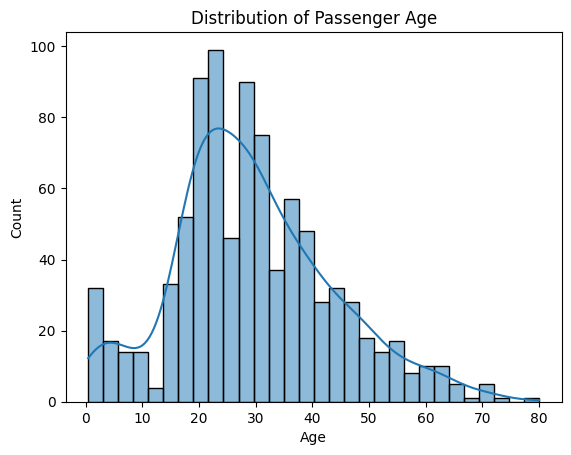

In [25]:
# TODO: Create a histogram of passenger ages

# Ensure 'Age_filled' column exists for plotting
if 'Age_filled' not in df.columns:
    age_median = df['Age'].median()
    df['Age_filled'] = df['Age'].fillna(age_median)

plt.figure()
sns.histplot(df["Age_filled"], bins=30, kde=True)
plt.title("Distribution of Passenger Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

/tmp/ipykernel_10734/74909507.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=surv_by_class, x="Pclass", y="Survived", palette="Blues")


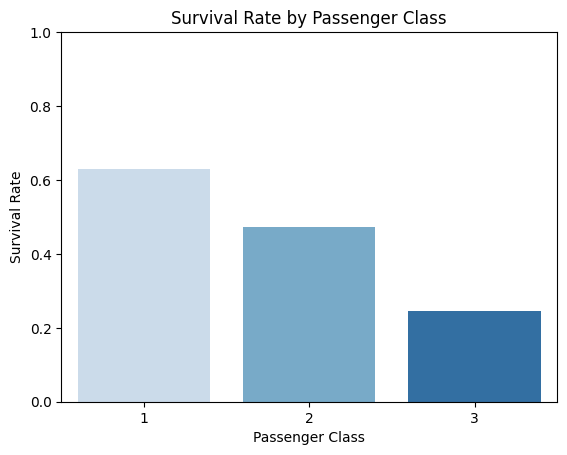

In [26]:
# TODO: Create a bar plot of survival rates by passenger class
plt.figure()
surv_by_class = df.groupby("Pclass")["Survived"].mean().reset_index()

sns.barplot(data=surv_by_class, x="Pclass", y="Survived", palette="Blues")
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.show()

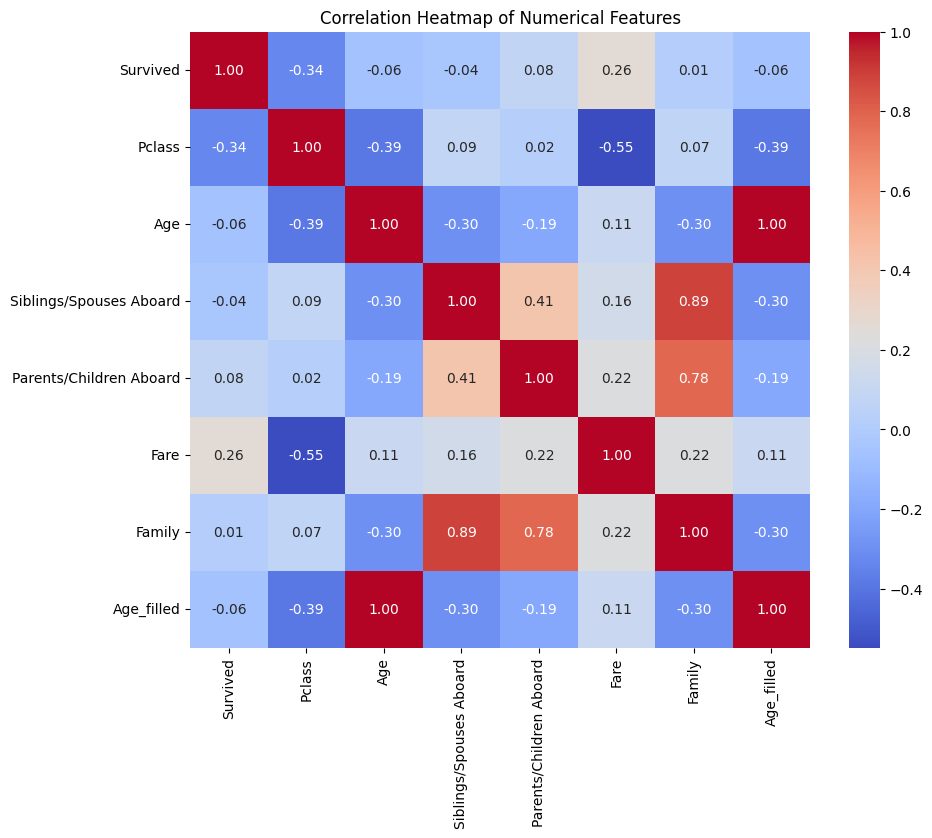

In [27]:
# TODO: Create a heatmap of correlation between numerical features
numeric_cols = df.select_dtypes(include=[np.number])
corr = numeric_cols.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

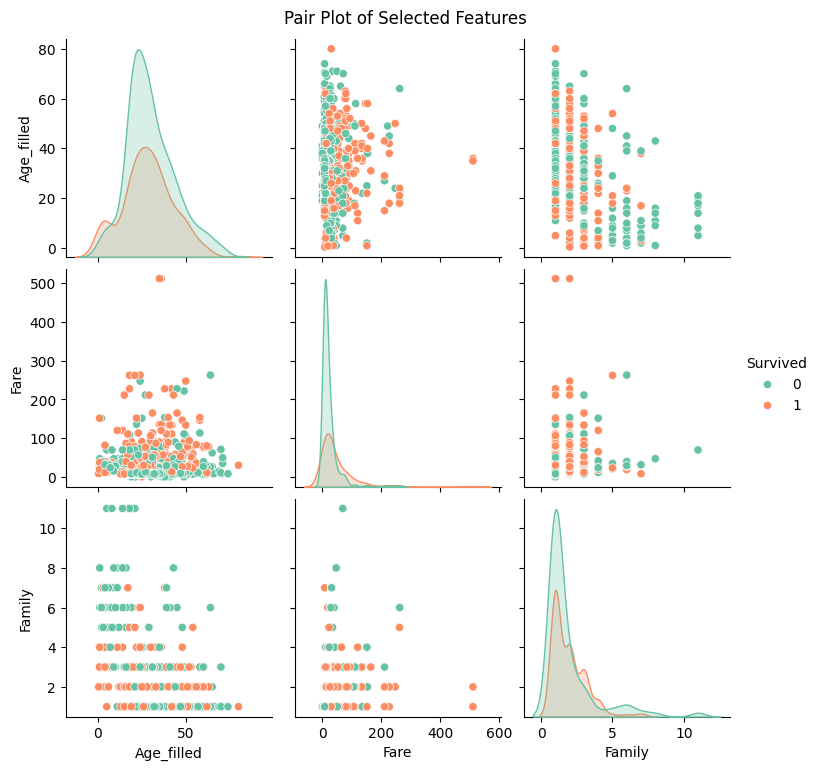

In [29]:
# TODO: Create a pair plot of 'Age', 'Fare', 'SibSp', and 'Parch', colored by 'Survived'
selected_features = ["Survived", "Pclass", "Sex", "Age_filled", "Fare", "Family"]
pairplot_df = df[selected_features].copy()
pairplot_df["Sex"] = pairplot_df["Sex"].astype("category")

sns.pairplot(
    pairplot_df,
    hue="Survived",
    vars=["Age_filled", "Fare", "Family"],
    palette="Set2"
)
plt.suptitle("Pair Plot of Selected Features", y=1.02)
plt.show()

### EDA Note: Visual patterns

- **Age histogram:** Shows concentration of passengers in young adult range; few very old passengers.
- **Survival by class:** Clear gradient—1st class highest survival, 3rd class lowest.
- **Correlations:** `Fare` correlates with `Pclass`; `FamilySize` relates to `SibSp` and `Parch`.
- **Pair plot:** Survivors tend to have higher fares and moderate family sizes.


## Task 8: Analyze survival rates

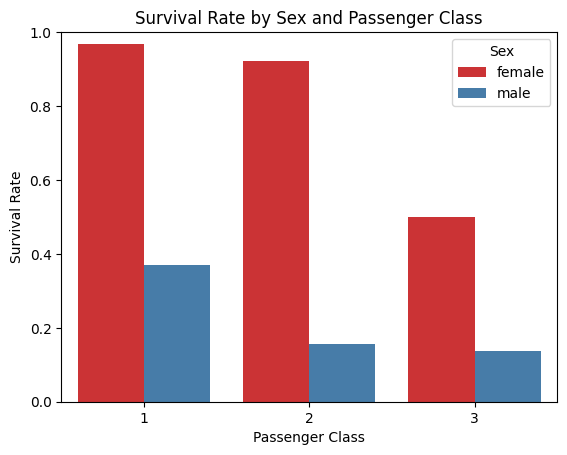

In [30]:
# TODO: Calculate and display survival rates by sex
survival_by_sex = (
    df.groupby(["Sex", "Pclass"])["Survived"]
    .mean()
    .reset_index()
)

plt.figure()
sns.barplot(
    data=survival_by_sex,
    x="Pclass",
    y="Survived",
    hue="Sex",
    palette="Set1"
)
plt.title("Survival Rate by Sex and Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.legend(title="Sex")
plt.show()

### EDA Note: Sex and class interaction

- **Insight:** Females in all classes generally have higher survival rates than males.
- **Observation:** Male passengers in 1st class show particularly high survival rates.


## Task 9: Analyze age distribution

/tmp/ipykernel_10734/486574844.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Survived", y="Age_filled", palette="Pastel1")


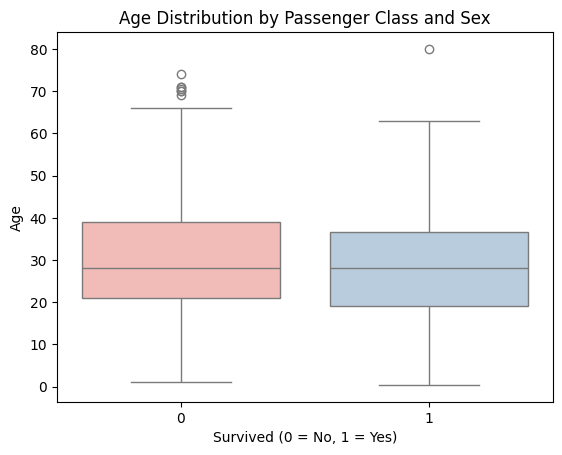

In [31]:
## TODO: Create a box plot of age distribution by passenger class and sex
plt.figure()
sns.boxplot(data=df, x="Survived", y="Age_filled", palette="Pastel1")
plt.title('Age Distribution by Passenger Class and Sex')
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Age")
plt.show()

### EDA Note: Age and survival

- **Observation:** Median ages of survivors and non-survivors may be similar, but spread differs.
- Very young children might have slightly higher survival due to evacuation priorities.


## Task 10: Analyze fare distribution

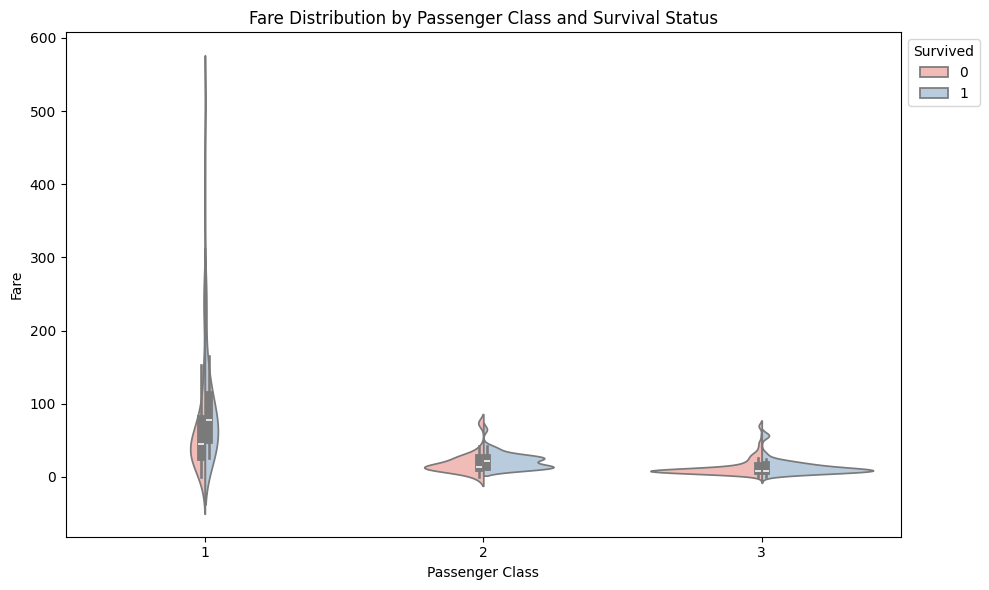

In [49]:
# TODO: Create a violin plot of fare distribution by passenger class and survival status
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x="Pclass", y="Fare", hue="Survived", palette="Pastel1", split=True)
plt.title('Fare Distribution by Passenger Class and Survival Status')
plt.xlabel("Passenger Class")
plt.ylabel("Fare")
plt.legend(title="Survived", loc="upper left", bbox_to_anchor=(1, 1)) # Add legend and place it outside
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

In [33]:
print("EDA tasks completed.")

EDA tasks completed.


## Summary of EDA Insights

- **Data quality:** Missing values mainly in `Age` and `Cabin`; handled `Age` via median imputation.
- **Feature engineering:** `FamilySize`, `Pclass_cat`, and `Cabin_flag` provide richer context for survival analysis.
- **Survival patterns:**
  - Higher survival in **1st class** and among **females**.
  - **3rd class males** show the lowest survival rates.
- **Age:** Most passengers are young adults; survival does not drastically differ by age, but children may have slight advantage.
- **Fare:** Strongly associated with class and survival; higher fares correlate with better outcomes.
- **FamilySize:** Very large families and solo travelers may have different survival probabilities, suggesting social and logistical factors.

These insights can guide further modeling (e.g., logistic regression) and feature selection for predictive tasks.
